<a href="https://colab.research.google.com/github/terrydw-hcc/ITAI-1371-ML-Labs/blob/main/Fantasy_Football_ML_Final_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Weekly Fantasy Football Player Performance Using Machine Learning

**Name:** Terry Williams  
**Course:** ITAI-1371 Introduction to Machine Learning  
**Institution:** Houston City College

This notebook is the code submission for the final project. It builds a regression pipeline to predict **weekly fantasy football points** using 2024 weekly performance data, lag features, and prior-season player statistics.


## Project Overview

**Goal:** Predict weekly fantasy football points for NFL players.  
**Problem type:** Regression  
**Target:** `points`  
**Data used:** 2024 weekly fantasy scores, 2023 season performance history, and supplemental uploaded CSV files.

### Modeling strategy
- Create **weekly lag features** such as previous-week points and rolling averages
- Merge in **previous season summary stats**
- Train and compare:
  - Linear Regression
  - Random Forest Regressor
  - Gradient Boosting Regressor

### Train/test split
- **Train:** Weeks 1–10
- **Test:** Weeks 11–14

This created a final modeling dataset with **4,407 rows** across **553 players**.


In [24]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

weekly_path = "data/weekly_fantasy_scores_2024_with_ids.csv"
performance_path = "data/performance_data_with_ids_cleaned_2021_2024.csv"

weekly = pd.read_csv(weekly_path)
perf = pd.read_csv(performance_path)

weekly = weekly.dropna(subset=["player_id", "week", "points"]).copy()
weekly["week"] = weekly["week"].astype(int)
weekly = weekly.sort_values(["player_id", "week"])

grp = weekly.groupby("player_id", group_keys=False)
weekly["lag1_points"] = grp["points"].shift(1).fillna(0)
weekly["lag2_points"] = grp["points"].shift(2).fillna(0)
weekly["rolling3_mean"] = grp["points"].shift(1).rolling(3, min_periods=1).mean().reset_index(level=0, drop=True).fillna(0)
weekly["rolling3_std"] = grp["points"].shift(1).rolling(3, min_periods=1).std().reset_index(level=0, drop=True).fillna(0)
weekly["season_to_date_avg"] = grp["points"].shift(1).expanding().mean().reset_index(level=0, drop=True).fillna(0)
weekly["season_to_date_sum"] = grp["points"].shift(1).expanding().sum().reset_index(level=0, drop=True).fillna(0)
weekly["played_prev_week"] = (~grp["points"].shift(1).isna()).astype(int)

perf23 = perf[perf["season"] == 2023].copy()
keep_cols = ["player_id","Age","G","GS","Cmp","Att","Yds","TD","Int","Att.1","Yds.1","Y/A","TD.1",
             "Tgt","Rec","Yds.2","Y/R","TD.2","Fmb","FL","FantPt","PPR","DKPt","FDPt","VBD","PosRank","OvRank","HalfPPR"]
perf23 = perf23[keep_cols].rename(columns={c: f"prev_{c}" for c in keep_cols if c != "player_id"})

df = weekly.merge(perf23, on="player_id", how="left")
df["rookie_or_missing_prev"] = df["prev_PPR"].isna().astype(int)

num_prev_cols = [c for c in df.columns if c.startswith("prev_") and pd.api.types.is_numeric_dtype(df[c])]
df[num_prev_cols] = df[num_prev_cols].fillna(0)
df["position"] = df["position"].fillna("UNK")
df["team"] = df["team"].fillna("UNK")

feature_cols = ["week","position","team","lag1_points","lag2_points","rolling3_mean","rolling3_std",
                "season_to_date_avg","season_to_date_sum","played_prev_week","rookie_or_missing_prev"] + num_prev_cols

X = df[feature_cols]
y = df["points"]

train_mask = df["week"] <= 10
X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

print("Train rows:", len(X_train))
print("Test rows:", len(X_test))
print("Players:", df["player_id"].nunique())
df.head()

Train rows: 3195
Test rows: 1212
Players: 553


,player_id,player_name,position,team,week,points,canonical_player_id,lag1_points,lag2_points,rolling3_mean,...,prev_FL,prev_FantPt,prev_PPR,prev_DKPt,prev_FDPt,prev_VBD,prev_PosRank,prev_OvRank,prev_HalfPPR,rookie_or_missing_prev
0,abdame001,Ameer Abdullah,RB,CAR,1,0.0,abdame001,0.0,0.0,0.000000,...,0.0,22.0,41.0,44.0,31.5,0.0,85.0,0.0,31.5,0
1,abdame001,Ameer Abdullah,RB,CAR,2,2.2,abdame001,0.0,0.0,0.000000,...,0.0,22.0,41.0,44.0,31.5,0.0,85.0,0.0,31.5,0
2,abdame001,Ameer Abdullah,RB,CAR,3,3.3,abdame001,2.2,0.0,1.100000,...,0.0,22.0,41.0,44.0,31.5,0.0,85.0,0.0,31.5,0
3,abdame001,Ameer Abdullah,RB,CAR,4,0.0,abdame001,3.3,2.2,1.833333,...,0.0,22.0,41.0,44.0,31.5,0.0,85.0,0.0,31.5,0
4,abdame001,Ameer Abdullah,RB,CAR,5,14.1,abdame001,0.0,3.3,1.833333,...,0.0,22.0,41.0,44.0,31.5,0.0,85.0,0.0,31.5,0


In [26]:

categorical = ["position", "team"]
numeric = [c for c in feature_cols if c not in categorical]

preprocess_lr = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical)
])

preprocess_tree = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ]), numeric),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical)
])

models = {
    "Linear Regression": Pipeline([
        ("prep", preprocess_lr),
        ("model", LinearRegression())
    ]),
    "Random Forest": Pipeline([
        ("prep", preprocess_tree),
        ("model", RandomForestRegressor(
            n_estimators=300,
            max_depth=12,
            min_samples_leaf=3,
            random_state=42,
            n_jobs=-1
        ))
    ]),
    "Gradient Boosting": Pipeline([
        ("prep", preprocess_tree),
        ("model", GradientBoostingRegressor(
            n_estimators=250,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ])
}

results = []
fitted_models = {}


for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)
    fitted_models[name] = pipeline

    rmse = math.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    results.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
results_df


,Model,RMSE,MAE,R2
0,Random Forest,6.483964,4.801958,0.387981
1,Gradient Boosting,6.501892,4.783694,0.384591
2,Linear Regression,6.664064,4.860758,0.353509


## Results Summary

Using the uploaded data and the time-based split, the models performed as follows:

| Model             |    RMSE |     MAE |       R2 |
|:------------------|--------:|--------:|---------:|
| Random Forest     | 6.48396 | 4.80196 | 0.387981 |
| Gradient Boosting | 6.50189 | 4.78369 | 0.384591 |
| Linear Regression | 6.66406 | 4.86076 | 0.353509 |


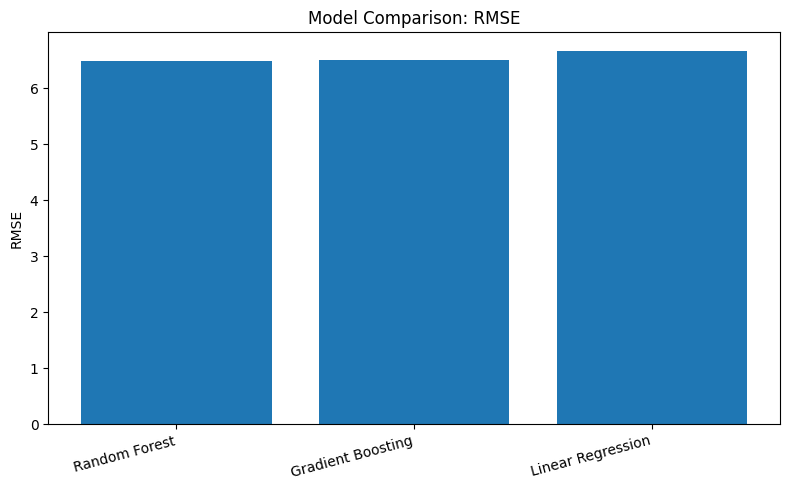

In [27]:

plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.title("Model Comparison: RMSE")
plt.ylabel("RMSE")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()


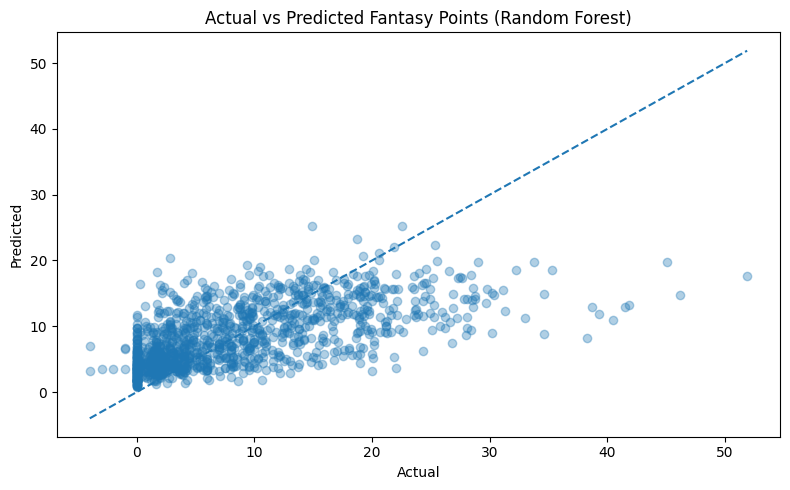

In [28]:

best_name = "Random Forest"
best_model = fitted_models[best_name]
best_preds = best_model.predict(X_test)

plt.figure(figsize=(8, 5))
plt.scatter(y_test, best_preds, alpha=0.35)
min_v = min(y_test.min(), best_preds.min())
max_v = max(y_test.max(), best_preds.max())
plt.plot([min_v, max_v], [min_v, max_v], linestyle="--")
plt.title(f"Actual vs Predicted Fantasy Points ({best_name})")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.tight_layout()
plt.show()


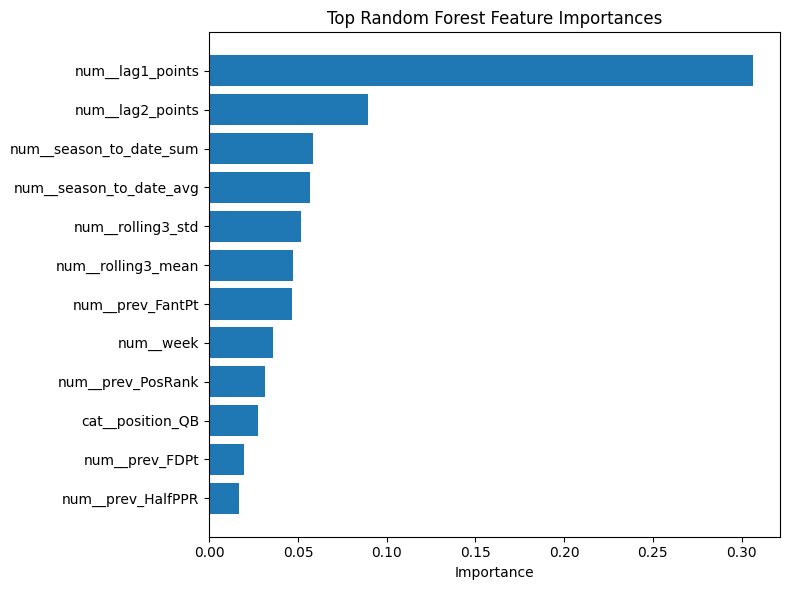

,feature,importance
1,num__lag1_points,0.306356
2,num__lag2_points,0.089606
6,num__season_to_date_sum,0.058683
5,num__season_to_date_avg,0.056840
4,num__rolling3_std,0.051870
3,num__rolling3_mean,0.047298
28,num__prev_FantPt,0.046528
0,num__week,0.035940
33,num__prev_PosRank,0.031572
37,cat__position_QB,0.027244


In [29]:

rf_model = fitted_models["Random Forest"]
prep = rf_model.named_steps["prep"]
rf = rf_model.named_steps["model"]

feature_names = prep.get_feature_names_out()
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

top_features = importance_df.head(12).iloc[::-1]

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importance_df.head(12)


## Discussion

The **Random Forest** model produced the best RMSE on the holdout weeks, with an RMSE of **6.484** and an R² of **0.388**.

### Key takeaways
- Recent player performance matters a lot. Lag features such as **previous-week points**, **lag-2 points**, and **season-to-date summaries** were among the most important predictors.
- Prior-season context still helped. Features like previous season fantasy production and position rank added signal.
- Ensemble models performed better than the linear baseline, which supports findings from the sports analytics literature that tree-based ensemble methods often capture nonlinear relationships better than simpler linear approaches.

### Limitations
- The weekly target data only covers **2024 weeks 1–14**
- Injury reports, opponent defensive strength, Vegas lines, and weather were not included
- Rookie players had limited historical context, so missing prior-season stats were filled with zeros and flagged with a rookie/missing-history indicator


## Conclusion

This project showed that machine learning can be used to predict weekly fantasy football points with moderate accuracy using public data. The strongest model in this notebook was Random Forest, and the most useful predictors were recent weekly performance features and prior-season fantasy production.

Future improvements could include:
- opponent matchup features
- injury status
- projected usage or snap share
- more seasons of weekly-level training data
- hyperparameter tuning with cross-validation
